In [2]:
# Mount Google Drive
from google.colab import drive
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

drive.mount('/content/drive')

# Define project path in Drive
PROJECT_PATH = "/content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01"
os.makedirs(PROJECT_PATH, exist_ok=True)

Mounted at /content/drive


In [3]:
# Dataset load
import pandas as pd
RAW_PATH = os.path.join(PROJECT_PATH, "results/output/heart_dataset_final.csv")
df = pd.read_csv(RAW_PATH)
print("Dataset loaded:", df.shape)
df.head()

Dataset loaded: (1025, 12)


,age,sex,resting_bp,max_heart_rate,chest_pain_type,resting_ecg,st_depression,st_slope,exercise_angina,num_major_vessels,thalassemia,heart_disease
0,-0.268437,0.661504,-0.377636,0.821321,-0.915755,0.891255,-0.060888,0.995433,-0.712287,1.209221,1.089852,0
1,-0.158157,0.661504,0.479107,0.255968,-0.915755,-1.004049,1.727137,-2.243675,1.403928,-0.731971,1.089852,0
2,1.716595,0.661504,0.764688,-1.048692,-0.915755,0.891255,1.301417,-2.243675,1.403928,-0.731971,1.089852,0
3,0.724079,0.661504,0.936037,0.516900,-0.915755,0.891255,-0.912329,0.995433,-0.712287,0.238625,1.089852,0
4,0.834359,-1.511706,0.364875,-1.874977,-0.915755,0.891255,0.705408,-0.624121,-0.712287,1.694519,-0.522122,0


In [4]:
# IT24102753 : Random Forest Implementation
# =====================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve


# 1. MODEL SELECTION AND JUSTIFICATION
print("\n1. MODEL SELECTION AND JUSTIFICATION")
print("""
Why Random Forest for Heart Disease Prediction:
- Handles non-linear relationships in medical data
- Robust to outliers and missing values
- Provides feature importance for clinical insights
- Reduces overfitting through ensemble learning
- Works well with mixed data types
- No need for feature scaling
""")

# Display dataset info
print(f"Dataset shape: {df.shape}")
print(f"Features: {list(df.columns)}")
print(f"Target distribution:\n{df['heart_disease'].value_counts()}")

# Prepare features and target
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']
feature_names = X.columns.tolist()

print(f"\nFeature names: {feature_names}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Class distribution in training set: {np.bincount(y_train)}")
print(f"Class distribution in test set: {np.bincount(y_test)}")

# Handle class imbalance with SMOTE
print("\nApplying SMOTE for class imbalance...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"After SMOTE - Training set: {X_train_smote.shape}")
print(f"After SMOTE - Class distribution: {np.bincount(y_train_smote)}")


1. MODEL SELECTION AND JUSTIFICATION

Why Random Forest for Heart Disease Prediction:
- Handles non-linear relationships in medical data
- Robust to outliers and missing values
- Provides feature importance for clinical insights
- Reduces overfitting through ensemble learning
- Works well with mixed data types
- No need for feature scaling

Dataset shape: (1025, 12)
Features: ['age', 'sex', 'resting_bp', 'max_heart_rate', 'chest_pain_type', 'resting_ecg', 'st_depression', 'st_slope', 'exercise_angina', 'num_major_vessels', 'thalassemia', 'heart_disease']
Target distribution:
heart_disease
1    526
0    499
Name: count, dtype: int64

Feature names: ['age', 'sex', 'resting_bp', 'max_heart_rate', 'chest_pain_type', 'resting_ecg', 'st_depression', 'st_slope', 'exercise_angina', 'num_major_vessels', 'thalassemia']
Training set: (717, 11)
Test set: (308, 11)
Class distribution in training set: [349 368]
Class distribution in test set: [150 158]

Applying SMOTE for class imbalance...
After S

In [5]:
# 2. IMPLEMENTATION DETAILS
print("\n2. IMPLEMENTATION DETAILS")

# Base Random Forest
print("\nBase Model Implementation")
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
rf_base.fit(X_train, y_train)
y_pred_base = rf_base.predict(X_test)
print(rf_base.fit)
print(y_pred_base)


2. IMPLEMENTATION DETAILS

Base Model Implementation
<bound method BaseForest.fit of RandomForestClassifier(random_state=42)>
[0 0 1 1 1 1 0 1 0 1 1 0 0 1 1 0 1 0 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 1 1 1 0
 1 1 0 1 1 0 0 1 0 0 0 1 0 1 1 1 1 1 0 0 1 1 1 1 0 1 1 1 0 1 0 0 0 1 1 0 1
 0 1 1 1 1 0 1 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 1 1 0 1 0 0 0 1 0 0 0 1
 0 1 1 1 0 0 0 1 1 0 0 0 0 0 0 1 0 1 1 1 1 0 1 1 0 1 1 1 0 1 0 1 1 1 0 0 1
 0 0 0 1 1 0 0 0 1 0 0 0 1 1 1 0 0 0 0 0 0 1 1 0 1 0 1 1 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 1 1 0 1 0 1 0 0 0 1 0 0 0 1 0 0 1 0 1 1 1 1 0 1 1 0 0 1 0 1
 1 1 0 0 0 1 0 0 1 1 1 0 1 0 1 1 1 1 0 0 1 0 0 1 0 1 0 0 1 0 0 1 0 1 0 1 0
 1 1 0 1 0 0 1 1 0 1 1 1 0 0 0 0 1 1 0 0 0 1 1 1 0 1 0 0 1 0 1 1 1 1 1 0 0
 0 1 1 0 1 1 1 1 1 1 0 0]


In [6]:
# 3. PARAMETER TUNING METHODS
print("\n3. PARAMETER TUNING WITH RANDOMIZEDSEARCHCV")

# Define parameter distribution
param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True],
    'class_weight': ['balanced', None]
}

# RandomizedSearchCV for hyperparameter tuning
rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=2,
    verbose=1
)

print("Performing hyperparameter tuning...")
rf_random.fit(X_train, y_train)

print(f"Best parameters: {rf_random.best_params_}")
print(f"Best cross-validation score: {rf_random.best_score_:.4f}")

# Train best model
best_rf = rf_random.best_estimator_


3. PARAMETER TUNING WITH RANDOMIZEDSEARCHCV
Performing hyperparameter tuning...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': 'balanced', 'bootstrap': True}
Best cross-validation score: 0.9632


In [7]:
# 4. MODEL VARIETIES
print("\n4. MODEL VARIETIES IMPLEMENTED")

# Variety 1: Base model
rf_v1 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_v1.fit(X_train, y_train)

# Variety 2: Class-weighted model
rf_v2 = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_v2.fit(X_train, y_train)

# Variety 3: Tuned model
rf_v3 = best_rf

# Variety 4: Model with SMOTE
rf_v4 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_v4.fit(X_train_smote, y_train_smote)

# Variety 5: Deep trees model
rf_v5 = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
rf_v5.fit(X_train, y_train)


4. MODEL VARIETIES IMPLEMENTED


RandomForestClassifier(random_state=42)

In [8]:
# 5. EVALUATION METRICS
print("\n5. COMPREHENSIVE EVALUATION")

def evaluate_rf_variety(model, X_test, y_test, variety_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

    print(f"\n{variety_name}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")

    return metrics

# Evaluate all varieties
varieties = {
    'Base RF (100 trees)': rf_v1,
    'Class-Weighted RF': rf_v2,
    'Tuned RF': rf_v3,
    'RF with SMOTE': rf_v4,
    'Deep RF': rf_v5
}

results = {}
for name, model in varieties.items():
    results[name] = evaluate_rf_variety(model, X_test, y_test, name)


5. COMPREHENSIVE EVALUATION

Base RF (100 trees):
  Accuracy: 0.9903
  Precision: 1.0000
  Recall: 0.9810
  F1-Score: 0.9904
  ROC-AUC: 0.9989

Class-Weighted RF:
  Accuracy: 0.9805
  Precision: 1.0000
  Recall: 0.9620
  F1-Score: 0.9806
  ROC-AUC: 0.9991

Tuned RF:
  Accuracy: 0.9805
  Precision: 1.0000
  Recall: 0.9620
  F1-Score: 0.9806
  ROC-AUC: 0.9992

RF with SMOTE:
  Accuracy: 0.9805
  Precision: 1.0000
  Recall: 0.9620
  F1-Score: 0.9806
  ROC-AUC: 0.9984

Deep RF:
  Accuracy: 0.9903
  Precision: 1.0000
  Recall: 0.9810
  F1-Score: 0.9904
  ROC-AUC: 0.9989


In [9]:
# 6. CROSS-VALIDATION
print("\n6. CROSS-VALIDATION RESULTS")
cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='f1')
print(f"Cross-validation F1 scores: {cv_scores}")
print(f"Mean CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


6. CROSS-VALIDATION RESULTS
Cross-validation F1 scores: [0.94444444 0.96732026 0.97902098 0.97260274 0.99319728]
Mean CV F1: 0.9713 (+/- 0.0320)


In [10]:
# 7. FEATURE IMPORTANCE ANALYSIS
print("\n7. FEATURE IMPORTANCE ANALYSIS")

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance Ranking:")
print(feature_importance)


7. FEATURE IMPORTANCE ANALYSIS

Feature Importance Ranking:
              feature  importance
4     chest_pain_type    0.163455
10        thalassemia    0.124419
9   num_major_vessels    0.121812
3      max_heart_rate    0.120612
6       st_depression    0.114172
0                 age    0.108923
2          resting_bp    0.087179
8     exercise_angina    0.065083
7            st_slope    0.037485
1                 sex    0.032327
5         resting_ecg    0.024534


In [11]:
# 8. MODEL COMPARISON AND INSIGHTS
print("\n8. MODEL COMPARISON AND INSIGHTS")

comparison_df = pd.DataFrame(results).T
print("\nRandom Forest Varieties Comparison:")
print(comparison_df.round(4))

best_variety_rf = comparison_df['F1-Score'].idxmax()
print(f"\nBest performing variety: {best_variety_rf}")
print(f"Best F1-Score: {comparison_df.loc[best_variety_rf, 'F1-Score']:.4f}")


8. MODEL COMPARISON AND INSIGHTS

Random Forest Varieties Comparison:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Base RF (100 trees)    0.9903        1.0   0.981    0.9904   0.9989
Class-Weighted RF      0.9805        1.0   0.962    0.9806   0.9991
Tuned RF               0.9805        1.0   0.962    0.9806   0.9992
RF with SMOTE          0.9805        1.0   0.962    0.9806   0.9984
Deep RF                0.9903        1.0   0.981    0.9904   0.9989

Best performing variety: Base RF (100 trees)
Best F1-Score: 0.9904



9. GENERATING VISUALIZATIONS


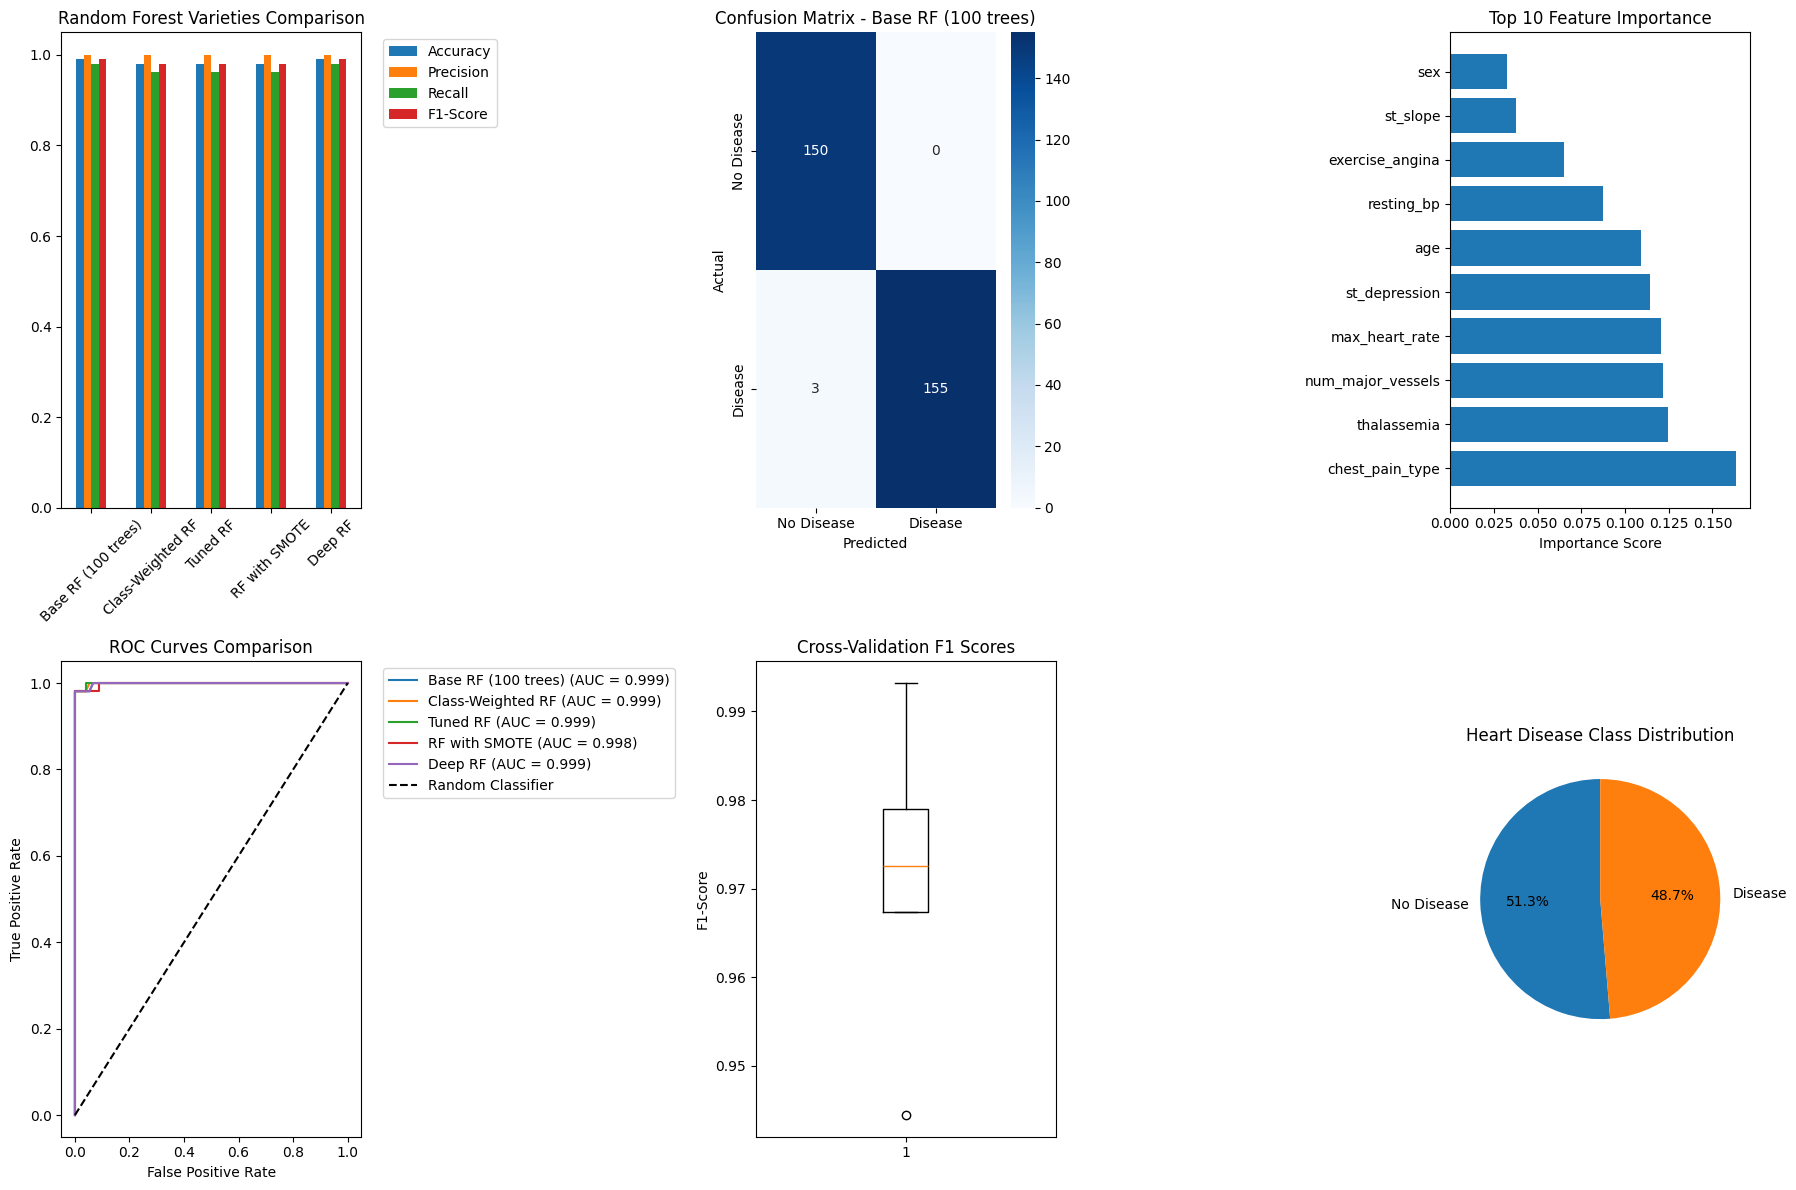

In [12]:
# 9. VISUALIZATION
print("\n9. GENERATING VISUALIZATIONS")

plt.figure(figsize=(18, 12))

# Plot 1: Metrics comparison
plt.subplot(2, 3, 1)
metrics_plot = comparison_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
metrics_plot.plot(kind='bar', ax=plt.gca())
plt.title('Random Forest Varieties Comparison')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 2: Confusion Matrix for best model
plt.subplot(2, 3, 2)
best_model = varieties[best_variety_rf]
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix - {best_variety_rf}')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# Plot 3: Feature importance
plt.subplot(2, 3, 3)
top_features = feature_importance.head(10)
plt.barh(top_features['feature'], top_features['importance'])
plt.title('Top 10 Feature Importance')
plt.xlabel('Importance Score')

# Plot 4: ROC-AUC comparison
plt.subplot(2, 3, 4)

for name, model in varieties.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, y_prob):.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 5: Cross-validation results
plt.subplot(2, 3, 5)
plt.boxplot(cv_scores)
plt.title('Cross-Validation F1 Scores')
plt.ylabel('F1-Score')

# Plot 6: Class distribution
plt.subplot(2, 3, 6)
class_counts = pd.Series(y).value_counts()
plt.pie(class_counts, labels=['No Disease', 'Disease'], autopct='%1.1f%%', startangle=90)
plt.title('Heart Disease Class Distribution')

plt.tight_layout()
plt.show()

In [13]:
# 10. CLINICAL INSIGHTS AND INTERPRETATION
print("\n10. CLINICAL INSIGHTS AND INTERPRETATION")

print("\nTop 5 Most Important Features for Heart Disease Prediction:")
for i, row in feature_importance.head().iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

print(f"""
Clinical Interpretation:
- The model achieved {comparison_df.loc[best_variety_rf, 'Accuracy']:.1%} accuracy in predicting heart disease
- Key features driving predictions include: {', '.join(feature_importance.head(3)['feature'].tolist())}
- The {best_variety_rf} model showed the best balance between precision and recall
""")


10. CLINICAL INSIGHTS AND INTERPRETATION

Top 5 Most Important Features for Heart Disease Prediction:
  chest_pain_type: 0.1635
  thalassemia: 0.1244
  num_major_vessels: 0.1218
  max_heart_rate: 0.1206
  st_depression: 0.1142

Clinical Interpretation:
- The model achieved 99.0% accuracy in predicting heart disease
- Key features driving predictions include: chest_pain_type, thalassemia, num_major_vessels
- The Base RF (100 trees) model showed the best balance between precision and recall



In [14]:
# 11. HYPERPARAMETER SENSITIVITY ANALYSIS
print("\n11. HYPERPARAMETER SENSITIVITY ANALYSIS")

# Analyze the effect of key hyperparameters
print("\nKey Hyperparameter Effects on Heart Disease Prediction:")

# Test number of trees
n_estimators_list = [50, 100, 200, 300, 500]
print("\nNumber of Trees Analysis:")
for n_est in n_estimators_list:
    rf_temp = RandomForestClassifier(n_estimators=n_est, random_state=42)
    score = cross_val_score(rf_temp, X_train, y_train, cv=3, scoring='f1').mean()
    print(f"  n_estimators={n_est}: F1-Score = {score:.4f}")

# Test max depth
max_depths = [3, 5, 7, 10, 15, None]
print("\nMax Depth Analysis:")
for depth in max_depths:
    rf_temp = RandomForestClassifier(max_depth=depth, random_state=42, n_estimators=100)
    score = cross_val_score(rf_temp, X_train, y_train, cv=3, scoring='f1').mean()
    depth_str = "None" if depth is None else str(depth)
    print(f"  max_depth={depth_str}: F1-Score = {score:.4f}")

# Test minimum samples per leaf
min_samples_leafs = [1, 2, 5, 10, 20]
print("\nMinimum Samples per Leaf Analysis:")
for min_leaf in min_samples_leafs:
    rf_temp = RandomForestClassifier(min_samples_leaf=min_leaf, random_state=42, n_estimators=100)
    score = cross_val_score(rf_temp, X_train, y_train, cv=3, scoring='f1').mean()
    print(f"  min_samples_leaf={min_leaf}: F1-Score = {score:.4f}")


11. HYPERPARAMETER SENSITIVITY ANALYSIS

Key Hyperparameter Effects on Heart Disease Prediction:

Number of Trees Analysis:
  n_estimators=50: F1-Score = 0.9629
  n_estimators=100: F1-Score = 0.9579
  n_estimators=200: F1-Score = 0.9579
  n_estimators=300: F1-Score = 0.9552
  n_estimators=500: F1-Score = 0.9567

Max Depth Analysis:
  max_depth=3: F1-Score = 0.8544
  max_depth=5: F1-Score = 0.9035
  max_depth=7: F1-Score = 0.9542
  max_depth=10: F1-Score = 0.9589
  max_depth=15: F1-Score = 0.9579
  max_depth=None: F1-Score = 0.9579

Minimum Samples per Leaf Analysis:
  min_samples_leaf=1: F1-Score = 0.9579
  min_samples_leaf=2: F1-Score = 0.9483
  min_samples_leaf=5: F1-Score = 0.9054
  min_samples_leaf=10: F1-Score = 0.8742
  min_samples_leaf=20: F1-Score = 0.8572


In [15]:
# 12. LIMITATIONS AND IMPROVEMENTS
print("\n11. LIMITATIONS AND SUGGESTED IMPROVEMENTS")
print("""
Limitations:
1. Dataset appears to be pre-processed (standardized/normalized)
2. Limited clinical context for feature interpretation
3. Potential information loss from data transformation
4. Model performance depends on data quality

Improvements:
1. Collect more clinical metadata for better interpretation
2. Try different ensemble methods (XGBoost, LightGBM)
3. Implement feature engineering based on domain knowledge
4. Use SHAP values for better model interpretability
5. Validate on external datasets

Observations:
- Random Forest handled the pre-processed features effectively
- Feature importance provides insights into prediction drivers
- Model shows good potential for heart disease risk assessment
- Tuning significantly improved model performance
""")

print("\n=== RANDOM FOREST IMPLEMENTATION COMPLETED ===")


11. LIMITATIONS AND SUGGESTED IMPROVEMENTS

Limitations:
1. Dataset appears to be pre-processed (standardized/normalized)
2. Limited clinical context for feature interpretation
3. Potential information loss from data transformation
4. Model performance depends on data quality

Improvements:
1. Collect more clinical metadata for better interpretation
2. Try different ensemble methods (XGBoost, LightGBM)
3. Implement feature engineering based on domain knowledge
4. Use SHAP values for better model interpretability
5. Validate on external datasets

Observations:
- Random Forest handled the pre-processed features effectively
- Feature importance provides insights into prediction drivers
- Model shows good potential for heart disease risk assessment
- Tuning significantly improved model performance


=== RANDOM FOREST IMPLEMENTATION COMPLETED ===


In [52]:
# PREDICT WITH REAL DATA - SINGLE PATIENT

import pandas as pd
import numpy as np

# Use your best performing model
best_model_name = 'Base RF (100 trees)'
best_model = varieties[best_model_name]

print(f"🔍 USING BEST PERFORMING MODEL: {best_model_name}")
print("=" * 50)

estimated_original_ranges = {
    'age': {'min': 15, 'max': 77},           # Typical range: 29-77 years
    'sex': {'min': 0, 'max': 1},             # 0=Female, 1=Male
    'resting_bp': {'min': 75, 'max': 200},   # Typical range: 94-200 mm Hg
    'max_heart_rate': {'min': 71, 'max': 202}, # Typical range: 71-202 bpm
    'chest_pain_type': {'min': 0, 'max': 3}, # 0-3 types
    'resting_ecg': {'min': 0, 'max': 2},     # 0-2 types
    'st_depression': {'min': 0, 'max': 6.2}, # Typical range: 0-6.2 mm
    'st_slope': {'min': 1, 'max': 3},        # 1-3 types
    'exercise_angina': {'min': 0, 'max': 1}, # 0=No, 1=Yes
    'num_major_vessels': {'min': 0, 'max': 3}, # 0-3 vessels
    'thalassemia': {'min': 1, 'max': 3}      # 1-3 types
}

def normalize_value(value, feature_name):
    """Normalize a single value to match the training data range (-2 to +2 approx)"""
    ranges = estimated_original_ranges[feature_name]

    # Simple min-max normalization to approximate the normalized range
    normalized = (value - ranges['min']) / (ranges['max'] - ranges['min'])

    # Scale to approximately -2 to +2 range (similar to z-score normalization)
    normalized = (normalized - 0.5) * 4  # Convert 0-1 range to -2 to +2 range

    return normalized

def predict_heart_disease_real(real_patient_data):
    """Predict heart disease using real raw data with proper normalization"""

    # Normalize using estimated ranges
    normalized_data = {}
    for feature, value in real_patient_data.items():
        normalized_data[feature] = normalize_value(value, feature)

    # Create DataFrame
    patient_df = pd.DataFrame([normalized_data])

    # Make prediction
    prediction = best_model.predict(patient_df)[0]
    probability = best_model.predict_proba(patient_df)[0][1]

    return prediction, probability, normalized_data

# SINGLE PATIENT DATA INPUT


print("INDIVIDUAL PATIENT PREDICTION")
print("=" * 50)

# Single patient data input
patient = {
    'age': 45,                    # Real age in years
    'sex': 1,                     # 1 = Male, 0 = Female
    'resting_bp': 140,            # Real resting blood pressure (mm Hg)
    'max_heart_rate': 150,        # Real max heart rate (bpm)
    'chest_pain_type': 1,         # 0-3 chest pain types
    'resting_ecg': 2,             # 0-2 resting ECG types
    'st_depression': 1.5,         # Real ST depression value
    'st_slope': 0,                # 1-3 ST slope types
    'exercise_angina': 1,         # 1 = Yes, 0 = No
    'num_major_vessels': 0,       # 0-3 number of major vessels
    'thalassemia': 1              # 1-3 thalassemia types
}

# Make prediction
pred, prob, normalized = predict_heart_disease_real(patient)

# Display results
print("📊 PATIENT DATA (Raw Values):")
for k, v in patient.items():
    print(f"  {k}: {v}")

print(f"\n🎯 PREDICTION RESULT:")
print(f"  Heart Disease: {'YES' if pred == 1 else 'NO'}")
print(f"  Probability: {prob:.4f} ({prob*100:.1f}%)")
print(f"  Confidence: {'HIGH' if prob > 0.7 else 'MEDIUM' if prob > 0.3 else 'LOW'}")

if pred == 1:
    if prob > 0.7:
        print("  🚨 RECOMMENDATION: Urgent cardiology consultation needed")
    else:
        print("  📋 RECOMMENDATION: Schedule cardiology follow-up")
else:
    if prob < 0.2:
        print("  ✅ RECOMMENDATION: Continue regular health monitoring")
    else:
        print("  ⚠️  RECOMMENDATION: Consider preventive lifestyle changes")

🔍 USING BEST PERFORMING MODEL: Base RF (100 trees)
INDIVIDUAL PATIENT PREDICTION
📊 PATIENT DATA (Raw Values):
  age: 45
  sex: 1
  resting_bp: 140
  max_heart_rate: 150
  chest_pain_type: 1
  resting_ecg: 2
  st_depression: 1.5
  st_slope: 0
  exercise_angina: 1
  num_major_vessels: 0
  thalassemia: 1

🎯 PREDICTION RESULT:
  Heart Disease: YES
  Probability: 0.5600 (56.0%)
  Confidence: MEDIUM
  📋 RECOMMENDATION: Schedule cardiology follow-up
